# Loans at Risk: Capturing Default — Validation

## Purpose

This notebook implements the validation stage of the *Loans at Risk: Capturing Default* project.

The analysis uses aligned datasets derived from the same underlying loan population:

- **Training set:** loans issued between 2007 and 2014  
- **Testing set:** loans issued in 2015  

The modeling population is restricted to loans with terminal outcomes in order to define a clear prediction target.

The purpose of this notebook is **not to train or compare predictive models**, but to evaluate whether the selected model can be used to support **lending decisions** and whether it provides an improvement over LendingClub’s internal grading system.

Specifically, this notebook assesses how predicted default probabilities translate into **acceptance policies**, **risk outcomes**, and **capital trade-offs**.

---

## Data Coverage and Baseline Scope

The modeling and validation analysis is restricted to loans with **application-time information** and a **clear observed repayment outcome**. This implies that the supervised modeling population consists of loans that were **approved and issued by LendingClub** and later observed to a terminal outcome.

In principle, evaluating LendingClub’s broader approval process would require access to rejected applications as well. Archived rejected-loan files appear to exist, but repeated download attempts produced source-side errors, so these data could not be incorporated into the project.

As a result, the analysis is conducted on the population of loans that LendingClub chose to accept and that can be observed to completion.

This has two implications:

- The model is trained and evaluated on loans with observable terminal outcomes, consistent with the project’s prediction boundary.
- The comparison with LendingClub’s internal grading system is therefore a comparison **within the accepted loan population**, not a full evaluation of LendingClub’s initial approval boundary across all applicants.

Accordingly, the notebook does not claim to reproduce or replace LendingClub’s complete underwriting process. Instead, it evaluates whether default risk can be more effectively ordered and managed within the set of loans that LendingClub chose to accept.

---

## Data Sources

The validation analysis combines two dataset representations derived from the same underlying loan population:

- **Selected model input datasets**  
  The datasets `selected_model_input_train.parquet` and `selected_model_input_test.parquet` contain the fully engineered feature space used by the final selected model. These datasets are loaded into `df_model_input_train` and `df_model_input_test`, and are used exclusively to generate predicted default probabilities. These datasets represent the final model input layer produced during the modeling stage and are not recomputed in this notebook.

- **`clean` datasets**  
  These datasets retain LendingClub’s internal grading system and contextual variables, including loan amount, that are required for decision-system comparison and capital evaluation.

Both dataset representations share a common row identifier (`row_id`), which is used to align model predictions with LendingClub grades and observed outcomes.

This alignment produces a unified validation dataset in which each loan is associated with:

- predicted default probability (model)  
- LendingClub grade (baseline system)  
- observed repayment outcome  
- loan characteristics relevant for decision evaluation  

This structure allows direct comparison between model-based and grade-based decision policies on the same set of loans.

---

## Analytical Framing

The modeling phase established that default risk can be predicted from application-time borrower information and identified a candidate model.

Validation shifts the focus from prediction to **decision use**.

A predictive model is only useful if it enables better decisions than existing alternatives. In this context, the relevant benchmark is LendingClub’s internal **grade-based risk classification**, which implicitly defines how borrower risk is evaluated at the time of application.

The central question becomes:

> Can a probability-based model improve lending outcomes relative to a grade-based policy when applied at the time of application?

Answering this requires translating model outputs into **operating policies** and evaluating their consequences.

---

## Decision Framework

Predicted default probabilities are converted into lending decisions using **threshold-based policies**.

For a given threshold:

- Loans with predicted default probability below the threshold are **accepted**
- Loans with predicted default probability above the threshold are **rejected**

Different thresholds represent different lending strategies, ranging from conservative (low tolerance for default risk) to more permissive (higher acceptance rates with increased risk exposure).

Model-based policies are evaluated across a range of thresholds to understand the trade-off between:

- **Default risk among accepted loans**
- **Volume of accepted loans**
- **False positives:** good loans rejected  
- **False negatives:** bad loans accepted  

These outcomes are compared directly to policies derived from **LendingClub grades**, which serve as the baseline decision system.

---

## Evaluation Dimensions

Validation focuses on three complementary dimensions.

#### 1. Risk Separation

- Assessed using ROC curves and AUC  
- Measures how well the model orders borrowers by risk  
- Compared to LendingClub’s grade-based system  
- Indicates ranking quality, not decision usefulness  

#### 2. Calibration

- Compares predicted probabilities to observed default rates  
- Evaluates whether probabilities reflect actual risk levels  
- Required for reliable threshold-based decisions  
- Miscalibration leads to systematic over- or underestimation of risk  

#### 3. Decision Outcomes

- Evaluates lending policies defined by probability thresholds  

For each threshold:

- Acceptance rate  
- Default rate among accepted loans  
- False positives (good loans rejected)  
- False negatives (bad loans accepted)  
- Loan volume and exposure  

Compared to LendingClub grade-based policies to assess whether the model:

- reduces default exposure  
- preserves or improves lending volume  
- improves the risk–opportunity trade-off  

---

## Stress Testing

In addition to standard evaluation, the model is tested on a **policy-exception population** that was excluded from model training.

This provides a check on whether the model generalizes beyond the standard underwriting population and whether its decision signals remain stable under distributional shifts.

---

## Structure

The notebook proceeds in five stages.

1. **Model Outputs**  
   Load predictions from the selected model for both training and testing datasets.

2. **Baseline Definition**  
   Define LendingClub grade-based acceptance policies to serve as a benchmark.

3. **Risk Evaluation**  
   Assess risk separation (ROC/AUC) and calibration of predicted probabilities.

4. **Policy Simulation**  
   Evaluate threshold-based lending policies and compare outcomes to grade-based policies.

5. **Decision Synthesis**  
   Identify candidate operating thresholds and summarize trade-offs in terms of risk, volume, and capital exposure.

---

## Outcome

The goal of this notebook is to determine whether a model-based decision policy can **improve lending outcomes relative to existing grading practices**, and to define how such a model would be used in practice.

The result is not a statement about model accuracy alone, but a **decision-oriented assessment** of whether and how the model should be deployed.

---

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()
project_root = None

for parent_path in (current_path, *current_path.parents):
    if (parent_path / "pyproject.toml").exists():
        project_root = parent_path
        break

if project_root is None:
    raise RuntimeError(
        f"Failed to resolve project root: pyproject.toml not found from {current_path}"
    )

src_path = project_root / "src"
if not src_path.exists():
    raise RuntimeError(f"Expected 'src' directory at: {src_path}")

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

{
    "stage": "bootstrap_import_path_ready",
    "project_root": str(project_root),
}

{'stage': 'bootstrap_import_path_ready',
 'project_root': 'D:\\Portfolio\\loans-at-risk-capturing-default'}

In [2]:
# ===========================================
# Imports: libraries and project modules
# ===========================================

from datetime import datetime, timezone
from typing import Callable
import uuid
import json

from IPython.display import display
import pandas as pd
import json
import joblib

import config.logging as log_config
import validation.data as vd
import validation.metrics as vm
import analysis.validation_artifacts as va
import plots.validation_figures as vf


In [3]:
# ===============================
# Paths and run context
# ===============================

logs_root = project_root / "logs"
logs_root.mkdir(parents=True, exist_ok=True)

PROJECT_LOG_FILE = logs_root / "project.log"

run_id = uuid.uuid4().hex[:10]
run_timestamp_utc = datetime.now(timezone.utc)

run_header = (
    "NEW RUN: "
    f"{run_timestamp_utc.strftime('%Y-%m-%d %H:%M:%S')} UTC | "
    f"RUN_ID={run_id}"
)

log_config.log_messages("\n" + "=" * 60, PROJECT_LOG_FILE)
log_config.log_messages(run_header, PROJECT_LOG_FILE)
log_config.log_messages("=" * 60 + "\n", PROJECT_LOG_FILE)

log: Callable[[str], None] = log_config.get_logger(PROJECT_LOG_FILE)
log("Validation notebook initialized")
log(f"project_root: {project_root}")
log(run_header)

{
    "stage": "run_started",
    "run_id": run_id,
    "utc_timestamp": run_timestamp_utc.isoformat(),
}

# ---------------------------------------------------------------
# Inputs for this notebook (processed, report)
# ---------------------------------------------------------------

# Model input datasets (engineered)
selected_model_input_train_file = project_root / "data" / "processed" / "selected_model_input_train_data.parquet"
selected_model_input_test_file = project_root / "data" / "processed" / "selected_model_input_test_data.parquet"

# Clean datasets
clean_train_data_file = project_root / "data" / "interim" / "clean_loan_data_2007_2014.parquet"
clean_test_data_file = project_root / "data" / "interim" / "clean_loan_data_2015.parquet"

# Validation datasets (built in this notebook)
validation_train_file = project_root / "data" / "processed" / "validation_dataset_train.parquet"
validation_test_file = project_root / "data" / "processed" / "validation_dataset_test.parquet"

# Model artifact
model_file = project_root / "models" / "catboost_shared_tuned.joblib"

# Metadata about the selected model and its performance
metadata_file = project_root / "data" / "processed" / "selected_model_metadata.json"

required_paths = {
    "selected_model_input_train_file": selected_model_input_train_file,
    "selected_model_input_test_file": selected_model_input_test_file,
    "clean_train_data_file": clean_train_data_file,
    "clean_test_data_file": clean_test_data_file,
    "model_file": model_file,
    "selected_model_metadata_file": metadata_file,
}


# Validation artifacts directories
artifacts_dir = project_root / "artifacts"
validation_artifacts_dir = artifacts_dir / "validation"
validation_tables_dir = validation_artifacts_dir / "tables"
validation_figures_dir = validation_artifacts_dir / "figures"

validation_train_file.parent.mkdir(parents=True, exist_ok=True)
validation_test_file.parent.mkdir(parents=True, exist_ok=True)
validation_tables_dir.mkdir(parents=True, exist_ok=True)
validation_figures_dir.mkdir(parents=True, exist_ok=True)

log(f"Selected model train parquet path: {selected_model_input_train_file}")
log(f"Selected model test parquet path: {selected_model_input_test_file}")
log(f"Clean train parquet path: {clean_train_data_file}")
log(f"Clean test parquet path: {clean_test_data_file}")
log(f"Model file path: {model_file}")
log(f"Model metadata file path: {metadata_file}")
log(f"Validation tables directory: {validation_tables_dir}")
log(f"Validation figures directory: {validation_figures_dir}")

In [4]:
# ----------------------------------------------------------------
# Check that all required input paths exist before proceeding
# ----------------------------------------------------------------

missing_paths = {name: str(path) for name, path in required_paths.items() if not path.exists()}

if missing_paths:
    log(f"Missing required paths: {missing_paths}")
    raise FileNotFoundError(
        {
            "stage": "validation_path_check",
            "error": "missing_required_paths",
            "missing": missing_paths,
        }
    )

path_check = {
    "stage": "validation_path_check",
    "status": "ok",
}

log(f"Path check result: {path_check}")

path_check

{'stage': 'validation_path_check', 'status': 'ok'}

In [5]:
# --------------------------------------------------------
# Load validation inputs
# --------------------------------------------------------

# -----------------------------
# Load datasets
# -----------------------------
df_model_input_train = pd.read_parquet(selected_model_input_train_file).copy()
df_model_input_test = pd.read_parquet(selected_model_input_test_file).copy()

df_clean_train = pd.read_parquet(clean_train_data_file).copy()
df_clean_test = pd.read_parquet(clean_test_data_file).copy()

log("Loading validation datasets, model artifact, and metadata")

# -----------------------------
# Load model
# -----------------------------
model = joblib.load(model_file)

# -----------------------------
# Load metadata
# -----------------------------
with open(metadata_file, "r") as f:
    metadata = json.load(f)

log(f"Loaded model input train dataset: {df_model_input_train.shape}")
log(f"Loaded model input test dataset: {df_model_input_test.shape}")
log(f"Loaded clean train dataset: {df_clean_train.shape}")
log(f"Loaded clean test dataset: {df_clean_test.shape}")
log(f"Loaded model artifact: {type(model).__name__}")
log(f"Loaded model metadata for: {metadata.get('selected_model')}")

required_metadata_keys = [
    "selected_model",
    "model_family",
    "preprocessing_branch",
    "target_column",
    "row_identifier",
    "train_data_path",
    "test_data_path",
]

missing_metadata_keys = [
    key for key in required_metadata_keys if key not in metadata
]

structural_checks = {
    "stage": "validation_inputs_loaded",
    "model_loaded": model is not None,
    "model_type": type(model).__name__,
    "model_has_predict_proba": hasattr(model, "predict_proba"),
    "model_input_train_rows": df_model_input_train.shape[0],
    "model_input_test_rows": df_model_input_test.shape[0],
    "clean_train_rows": df_clean_train.shape[0],
    "clean_test_rows": df_clean_test.shape[0],
    "model_input_train_has_row_id": "row_id" in df_model_input_train.columns,
    "model_input_test_has_row_id": "row_id" in df_model_input_test.columns,
    "clean_train_has_row_id": "row_id" in df_clean_train.columns,
    "clean_test_has_row_id": "row_id" in df_clean_test.columns,
    "model_input_train_has_target": metadata.get("target_column") in df_model_input_train.columns,
    "model_input_test_has_target": metadata.get("target_column") in df_model_input_test.columns,
    "clean_train_has_target": metadata.get("target_column") in df_clean_train.columns,
    "clean_test_has_target": metadata.get("target_column") in df_clean_test.columns,
    "train_row_count_match": df_model_input_train.shape[0] == df_clean_train.shape[0],
    "test_row_count_match": df_model_input_test.shape[0] == df_clean_test.shape[0],
    "metadata_train_path_match": metadata.get("train_data_path") == str(selected_model_input_train_file),
    "metadata_test_path_match": metadata.get("test_data_path") == str(selected_model_input_test_file),
    "missing_metadata_keys": missing_metadata_keys,
}

log(str(structural_checks))

structural_checks

{'stage': 'validation_inputs_loaded',
 'model_loaded': True,
 'model_type': 'CatBoostClassifier',
 'model_has_predict_proba': True,
 'model_input_train_rows': 282945,
 'model_input_test_rows': 60012,
 'clean_train_rows': 466287,
 'clean_test_rows': 421095,
 'model_input_train_has_row_id': True,
 'model_input_test_has_row_id': True,
 'clean_train_has_row_id': True,
 'clean_test_has_row_id': True,
 'model_input_train_has_target': True,
 'model_input_test_has_target': True,
 'clean_train_has_target': False,
 'clean_test_has_target': False,
 'train_row_count_match': False,
 'test_row_count_match': False,
 'metadata_train_path_match': True,
 'metadata_test_path_match': True,
 'missing_metadata_keys': ['row_identifier']}

## Clean Population Alignment

The validation stage combines two data representations that serve different roles.

The model is trained and evaluated on the engineered model-input datasets. These datasets are restricted to loans with terminal outcomes and reflect the exact population used during modeling. They define the row universe for which predictions are available.

The clean datasets, in contrast, retain the original variables required for interpretation and decision analysis, such as LendingClub grade and raw loan amount. However, these datasets are not restricted to the modeling population and therefore contain additional observations that were not used during model training.

Before validation can proceed, these two representations must be aligned to the same row universe.

---

### Alignment Principle

Validation is performed on the population for which the model produces predictions. This implies that the clean dataset must be restricted to the set of loans present in the model-input dataset.

The alignment is therefore defined as:

- keep all rows in `df_clean` whose `row_id` appears in `df_model_input`
- discard all other rows

This produces a clean validation dataset that:

- matches the modeled population exactly  
- retains all contextual variables required for interpretation  
- avoids mixing transformed and raw representations of the same variables  

---

### Target Construction

The model-input datasets already contain the binary target variable. The clean datasets does not.

If the target column is not present in the clean dataset, it is reconstructed from `loan_status` using the same mapping applied during modeling. This ensures that:

- the definition of default is consistent across modeling and validation  
- the observed outcome used for evaluation matches the training target  

---

### Resulting Dataset

The result of this step is a clean validation dataset that:

- contains exactly the same loans as the model-input dataset  
- includes the binary target variable  
- retains LendingClub grade and other contextual features  

This dataset forms the base for all subsequent validation steps, including prediction alignment, risk evaluation, and policy simulation.

---

In [6]:
# ---------------------------------------------------------------------------------
# Prepare clean validation datasets by aligning clean and model input datasets
# ---------------------------------------------------------------------------------

df_clean_validation_train = vd.prepare_clean_validation_data(
    df_clean=df_clean_train,
    df_model_input=df_model_input_train,
    target_column=metadata["target_column"],
    row_identifier_column="row_id",
    log=log,
)

log("Preparing clean validation dataset (train)")


df_clean_validation_test = vd.prepare_clean_validation_data(
    df_clean=df_clean_test,
    df_model_input=df_model_input_test,
    target_column=metadata["target_column"],
    row_identifier_column="row_id",
    log=log,
)

log("Preparing clean validation dataset (test)")

{
    "stage": "clean_validation_dataset_prepared",
    "train_rows": df_clean_validation_train.shape[0],
    "test_rows": df_clean_validation_test.shape[0],
    "train_has_target": metadata["target_column"] in df_clean_validation_train.columns,
    "test_has_target": metadata["target_column"] in df_clean_validation_test.columns,
}

{'stage': 'clean_validation_dataset_prepared',
 'train_rows': 282945,
 'test_rows': 60012,
 'train_has_target': True,
 'test_has_target': True}

## 1. Model Outputs

The previous step established a clean validation dataset aligned to the modeled population. This dataset contains the observed outcomes and contextual variables required for evaluation, but does not yet include model predictions.

This section introduces the model outputs. The selected model is applied to the engineered model-input datasets to generate predicted default probabilities for each loan. These predictions represent the model’s estimate of the likelihood of default at the time of application. The model-input datasets are used exclusively for scoring, as they contain the transformed feature space required by the model. The clean validation datasets are not used for prediction.

The resulting predictions are then aligned with the clean validation datasets using the row-level identifier. This produces a unified validation dataset in which each loan is associated with:

- predicted default probability  
- observed outcome (`target_default`)  
- LendingClub grade  
- loan characteristics (e.g., loan amount)  

This dataset forms the basis for all subsequent validation analyses, including risk separation, calibration, and policy evaluation.

---

In [7]:
# --------------------------------------------------------------------------------------------------------------------
# Build validation datasets by merging clean validation datasets with model input datasets and adding predictions
# --------------------------------------------------------------------------------------------------------------------

df_validation_train = vd.build_validation_dataset(
    df_model_input=df_model_input_train,
    df_clean=df_clean_validation_train,
    model=model,
    target_column=metadata["target_column"],
    row_identifier_column="row_id",
    log=log,
)

log(f"Validation dataset built (train): {df_validation_train.shape}")

df_validation_test = vd.build_validation_dataset(
    df_model_input=df_model_input_test,
    df_clean=df_clean_validation_test,
    model=model,
    target_column=metadata["target_column"],
    row_identifier_column="row_id",
    log=log,
)

log(f"Validation dataset built (test): {df_validation_test.shape}")

{
    "stage": "validation_dataset_built",
    "train_rows": df_validation_train.shape[0],
    "test_rows": df_validation_test.shape[0],
    "train_columns": df_validation_train.shape[1],
    "test_columns": df_validation_test.shape[1],
    "train_has_predictions": bool(df_validation_train["predicted_default_probability"].notna().all()),
	"test_has_predictions": bool(df_validation_test["predicted_default_probability"].notna().all()),
}

{'stage': 'validation_dataset_built',
 'train_rows': 282945,
 'test_rows': 60012,
 'train_columns': 92,
 'test_columns': 92,
 'train_has_predictions': True,
 'test_has_predictions': True}

In [8]:
# --------------------------------------------------------
# Save validation datasets
# --------------------------------------------------------

df_validation_train.to_parquet(validation_train_file)
df_validation_test.to_parquet(validation_test_file)

log(f"Validation dataset saved (train): {validation_train_file}")
log(f"Validation dataset saved (test): {validation_test_file}")

{
    "stage": "validation_dataset_saved",
    "train_path": str(validation_train_file),
    "test_path": str(validation_test_file),
    "train_rows": df_validation_train.shape[0],
    "test_rows": df_validation_test.shape[0],
}

{'stage': 'validation_dataset_saved',
 'train_path': 'D:\\Portfolio\\loans-at-risk-capturing-default\\data\\processed\\validation_dataset_train.parquet',
 'test_path': 'D:\\Portfolio\\loans-at-risk-capturing-default\\data\\processed\\validation_dataset_test.parquet',
 'train_rows': 282945,
 'test_rows': 60012}

## Model Outputs — Summary

This section generated predicted default probabilities using the selected model and aligned these predictions with the clean validation datasets.

The model was applied to the engineered model-input datasets to produce probability estimates for each loan. These predictions were then merged with the aligned clean datasets using the row-level identifier. The result is a unified validation dataset in which each loan is associated with:

- predicted default probability  
- observed outcome (`target_default`)  
- LendingClub grade  
- loan characteristics (e.g., loan amount)  

These datasets were persisted to ensure that all subsequent analysis operates on a stable and reproducible base.

The validation datasets now represent the full decision context: model predictions, realized outcomes, and the baseline system.

---

### Next Step

The next section evaluates **risk separation**.

This focuses on whether the model provides a stronger ordering of borrower risk than LendingClub’s grade-based system, using ROC curves and AUC as primary measures.

---

## 2. Baseline Definition

In [9]:
# --------------------------------------------------------
# Summarize grade structure in validation datasets
# --------------------------------------------------------

df_grade_structure_train, df_subgrade_distribution_train = vd.summarize_grade_structure(
    df=df_validation_train,
    grade_column="grade",
    subgrade_column="sub_grade",
    log=log,
)

log(
    {
        "stage": "grade_structure_summarized",
        "split": "train",
        "grade_rows": df_grade_structure_train.shape[0],
        "grade_columns": df_grade_structure_train.shape[1],
        "subgrade_rows": df_subgrade_distribution_train.shape[0],
        "subgrade_columns": df_subgrade_distribution_train.shape[1],
        "grades": df_grade_structure_train["grade"].tolist(),
    }
)

df_grade_structure_test, df_subgrade_distribution_test = vd.summarize_grade_structure(
    df=df_validation_test,
    grade_column="grade",
    subgrade_column="sub_grade",
    log=log,
)

log(
    {
        "stage": "grade_structure_summarized",
        "split": "test",
        "grade_rows": df_grade_structure_test.shape[0],
        "grade_columns": df_grade_structure_test.shape[1],
        "subgrade_rows": df_subgrade_distribution_test.shape[0],
        "subgrade_columns": df_subgrade_distribution_test.shape[1],
        "grades": df_grade_structure_test["grade"].tolist(),
    }
)

df_grade_structure_train_display = df_grade_structure_train.copy()
df_grade_structure_train_display["split"] = "train"

df_grade_structure_test_display = df_grade_structure_test.copy()
df_grade_structure_test_display["split"] = "test"

df_grade_structure_combined = pd.concat(
    [df_grade_structure_train_display, df_grade_structure_test_display],
    axis=0,
    ignore_index=True,
)

# Enforce train → test ordering
df_subgrade_distribution_train_display = df_subgrade_distribution_train.copy()
df_subgrade_distribution_train_display["split"] = "train"

df_subgrade_distribution_test_display = df_subgrade_distribution_test.copy()
df_subgrade_distribution_test_display["split"] = "test"

df_subgrade_distribution_combined = pd.concat(
    [df_subgrade_distribution_train_display, df_subgrade_distribution_test_display],
    axis=0,
    ignore_index=True,
)

df_subgrade_distribution_table = va.build_subgrade_distribution_table(
    df_subgrade_distribution=df_subgrade_distribution_combined,
    split_column="split",
    grade_column="grade",
    subgrade_column="sub_grade",
    count_column="loan_count",
    log=log,
)

log(
    {
        "stage": "subgrade_distribution_table_built",
        "rows": df_subgrade_distribution_table.shape[0],
        "columns": df_subgrade_distribution_table.shape[1],
    }
)

df_grade_structure_combined["split"] = pd.Categorical(
    df_grade_structure_combined["split"],
    categories=["train", "test"],
    ordered=True,
)

df_subgrade_distribution_table["split"] = pd.Categorical(
    df_subgrade_distribution_table["split"],
    categories=["train", "test"],
    ordered=True,
)

# --------------------------------------------------------
# Save subgrade distribution artifact
# --------------------------------------------------------

subgrade_distribution_table_file = validation_tables_dir / "subgrade_distribution_table.csv"

df_subgrade_distribution_table.to_csv(subgrade_distribution_table_file, index=False)

log(
    {
        "stage": "subgrade_distribution_table_saved",
        "path": str(subgrade_distribution_table_file),
        "rows": df_subgrade_distribution_table.shape[0],
        "columns": df_subgrade_distribution_table.shape[1],
    }
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(
        df_grade_structure_combined[
            [
                "split",
                "grade",
                "loan_count",
                "distinct_subgrades",
                "missing_subgrade_count",
                "missing_subgrade_rate",
            ]
        ].sort_values(["split", "grade"])
    )

    display(
        df_subgrade_distribution_table.sort_values(["split", "grade"])
    )

,split,grade,loan_count,distinct_subgrades,missing_subgrade_count,missing_subgrade_rate
0,train,a,47409,5,0,0.0
1,train,b,87183,5,0,0.0
2,train,c,72413,5,0,0.0
3,train,d,45044,5,0,0.0
4,train,e,20564,5,0,0.0
5,train,f,8177,5,0,0.0
6,train,g,2155,5,0,0.0
7,test,a,8116,5,0,0.0
8,test,b,14323,5,0,0.0
9,test,c,17400,5,0,0.0


,split,grade,a1,a2,a3,a4,a5,b1,b2,b3,b4,b5,c1,c2,c3,c4,c5,d1,d2,d3,d4,d5,e1,e2,e3,e4,e5,f1,f2,f3,f4,f5,g1,g2,g3,g4,g5
7,train,a,6784,6913,8037,12209,13466,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,train,b,0,0,0,0,0,13958,17108,20901,19400,15816,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,train,c,0,0,0,0,0,0,0,0,0,0,16651,15787,14295,13358,12322,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10,train,d,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11103,10185,8871,8151,6734,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
11,train,e,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5016,5005,4012,3534,2997,0,0,0,0,0,0,0,0,0,0
12,train,f,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2362,1868,1681,1267,999,0,0,0,0,0
13,train,g,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,726,525,365,283,256
0,test,a,1113,1289,1225,1825,2664,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,test,b,0,0,0,0,0,2378,2595,2830,3261,3259,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,test,c,0,0,0,0,0,0,0,0,0,0,3596,3665,3526,3599,3014,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
# -----------------------------------------------------------------------
# Build, save, and display normalized subgrade distribution artifact
# -----------------------------------------------------------------------

df_subgrade_distribution_normalized = va.build_normalized_subgrade_distribution_table(
    df_subgrade_distribution_table=df_subgrade_distribution_table,
    split_column="split",
    grade_column="grade",
    log=log,
)

# Enforce train → test ordering
df_subgrade_distribution_normalized["split"] = pd.Categorical(
    df_subgrade_distribution_normalized["split"],
    categories=["train", "test"],
    ordered=True,
)

# Sort once and reuse
df_subgrade_distribution_normalized = df_subgrade_distribution_normalized.sort_values(
    ["split", "grade"]
)

log(
    {
        "stage": "subgrade_distribution_normalized_built",
        "rows": df_subgrade_distribution_normalized.shape[0],
        "columns": df_subgrade_distribution_normalized.shape[1],
    }
)

# Save artifact
subgrade_distribution_normalized_file = (
    validation_tables_dir / "subgrade_distribution_normalized_table.csv"
)

df_subgrade_distribution_normalized.to_csv(
    subgrade_distribution_normalized_file,
    index=False,
)

log(
    {
        "stage": "subgrade_distribution_normalized_saved",
        "path": str(subgrade_distribution_normalized_file),
    }
)

# display normalized subgrade distribution table
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_subgrade_distribution_normalized)

,split,grade,a1,a2,a3,a4,a5,b1,b2,b3,b4,b5,c1,c2,c3,c4,c5,d1,d2,d3,d4,d5,e1,e2,e3,e4,e5,f1,f2,f3,f4,f5,g1,g2,g3,g4,g5
7,train,a,0.143095,0.145816,0.169525,0.257525,0.284039,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,train,b,0.000000,0.000000,0.000000,0.000000,0.000000,0.160100,0.196231,0.239737,0.222520,0.181412,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,train,c,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.229945,0.218013,0.197409,0.184470,0.170163,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,train,d,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.246492,0.226112,0.196941,0.180956,0.149498,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11,train,e,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.243921,0.243387,0.195098,0.171854,0.145740,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12,train,f,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.288859,0.228446,0.205577,0.154947,0.122172,0.000000,0.000000,0.000000,0.000000,0.000000
13,train,g,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.336891,0.243619,0.169374,0.131323,0.118794
0,test,a,0.137137,0.158822,0.150936,0.224864,0.328241,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,test,b,0.000000,0.000000,0.000000,0.000000,0.000000,0.166027,0.181177,0.197584,0.227676,0.227536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,test,c,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.206667,0.210632,0.202644,0.206839,0.173218,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


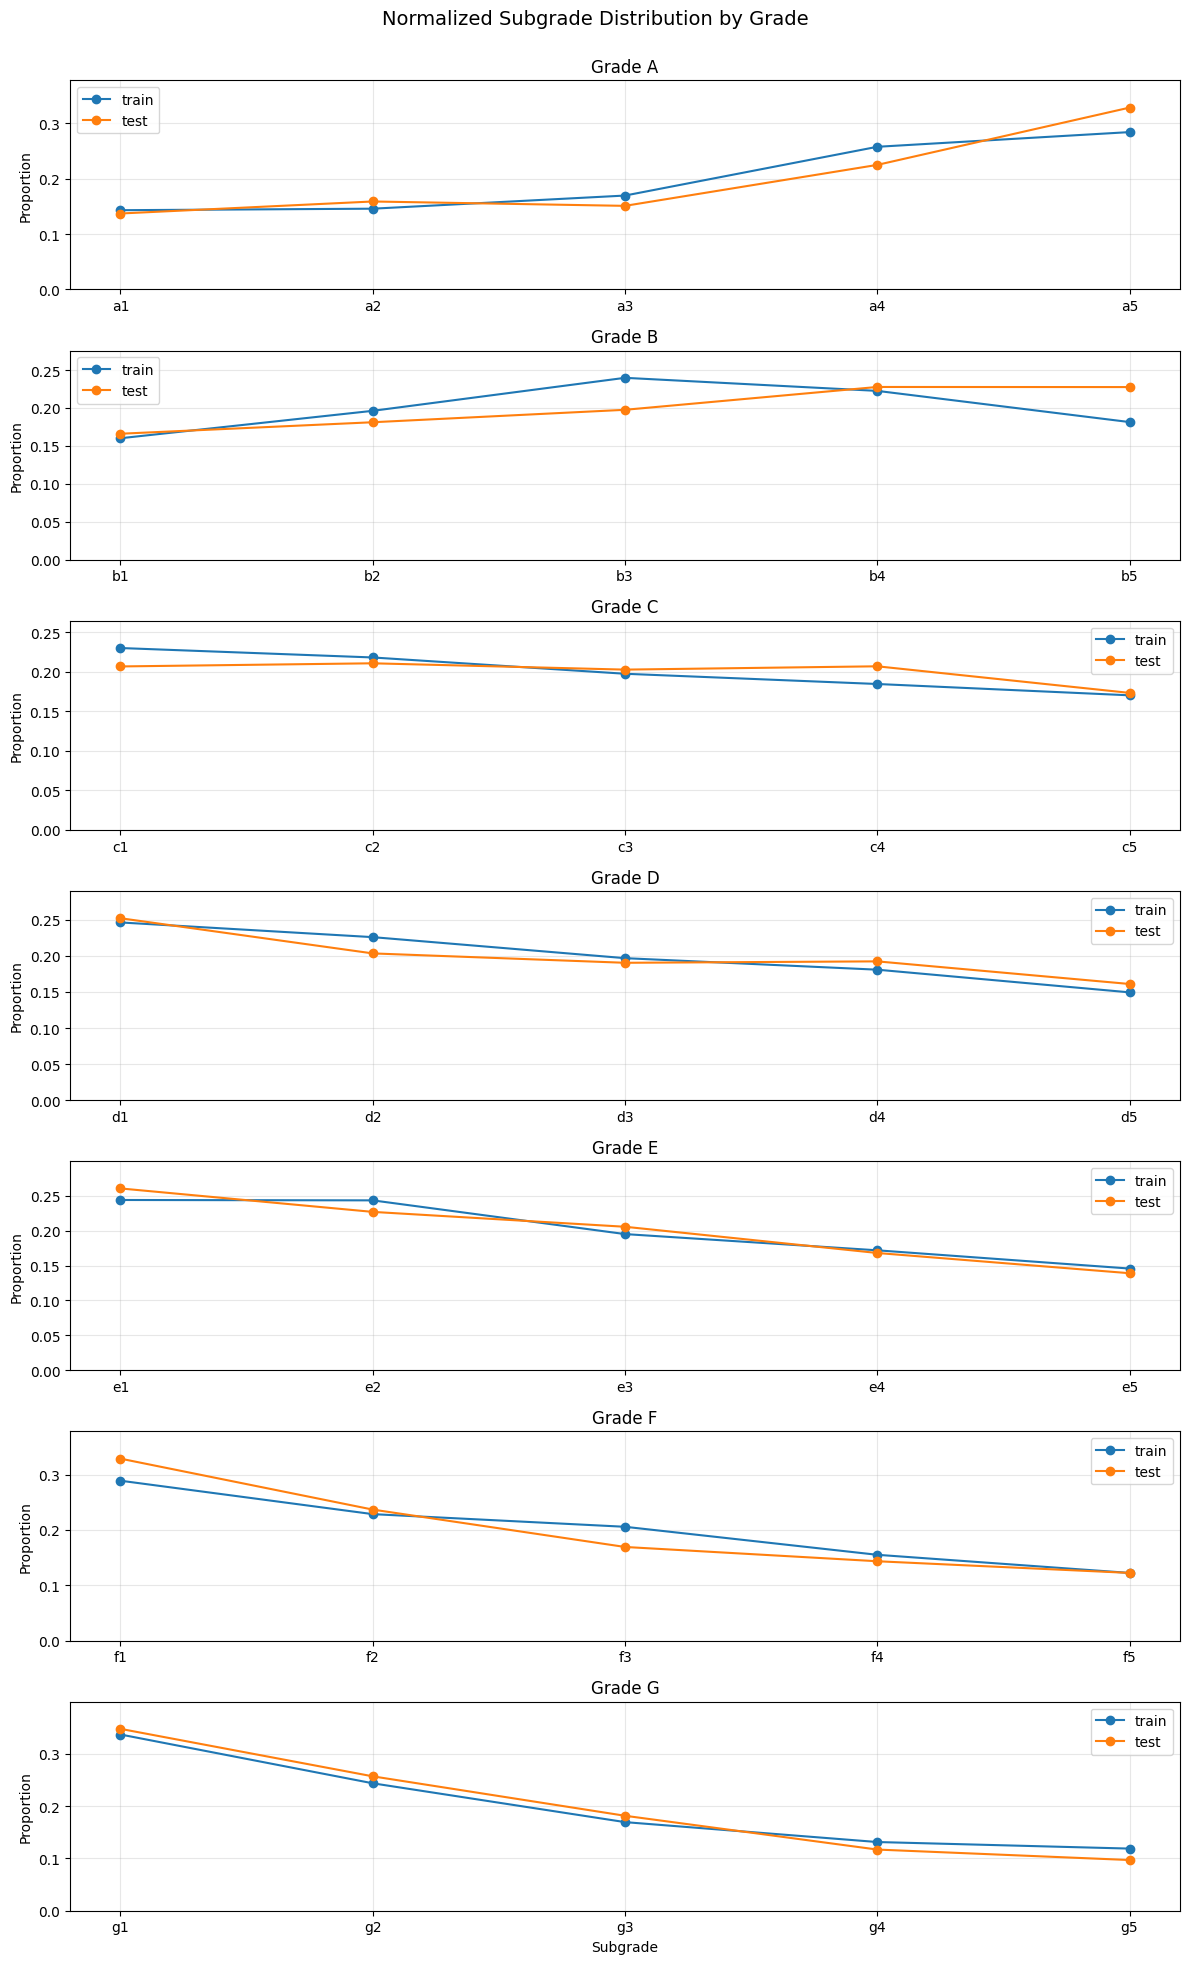

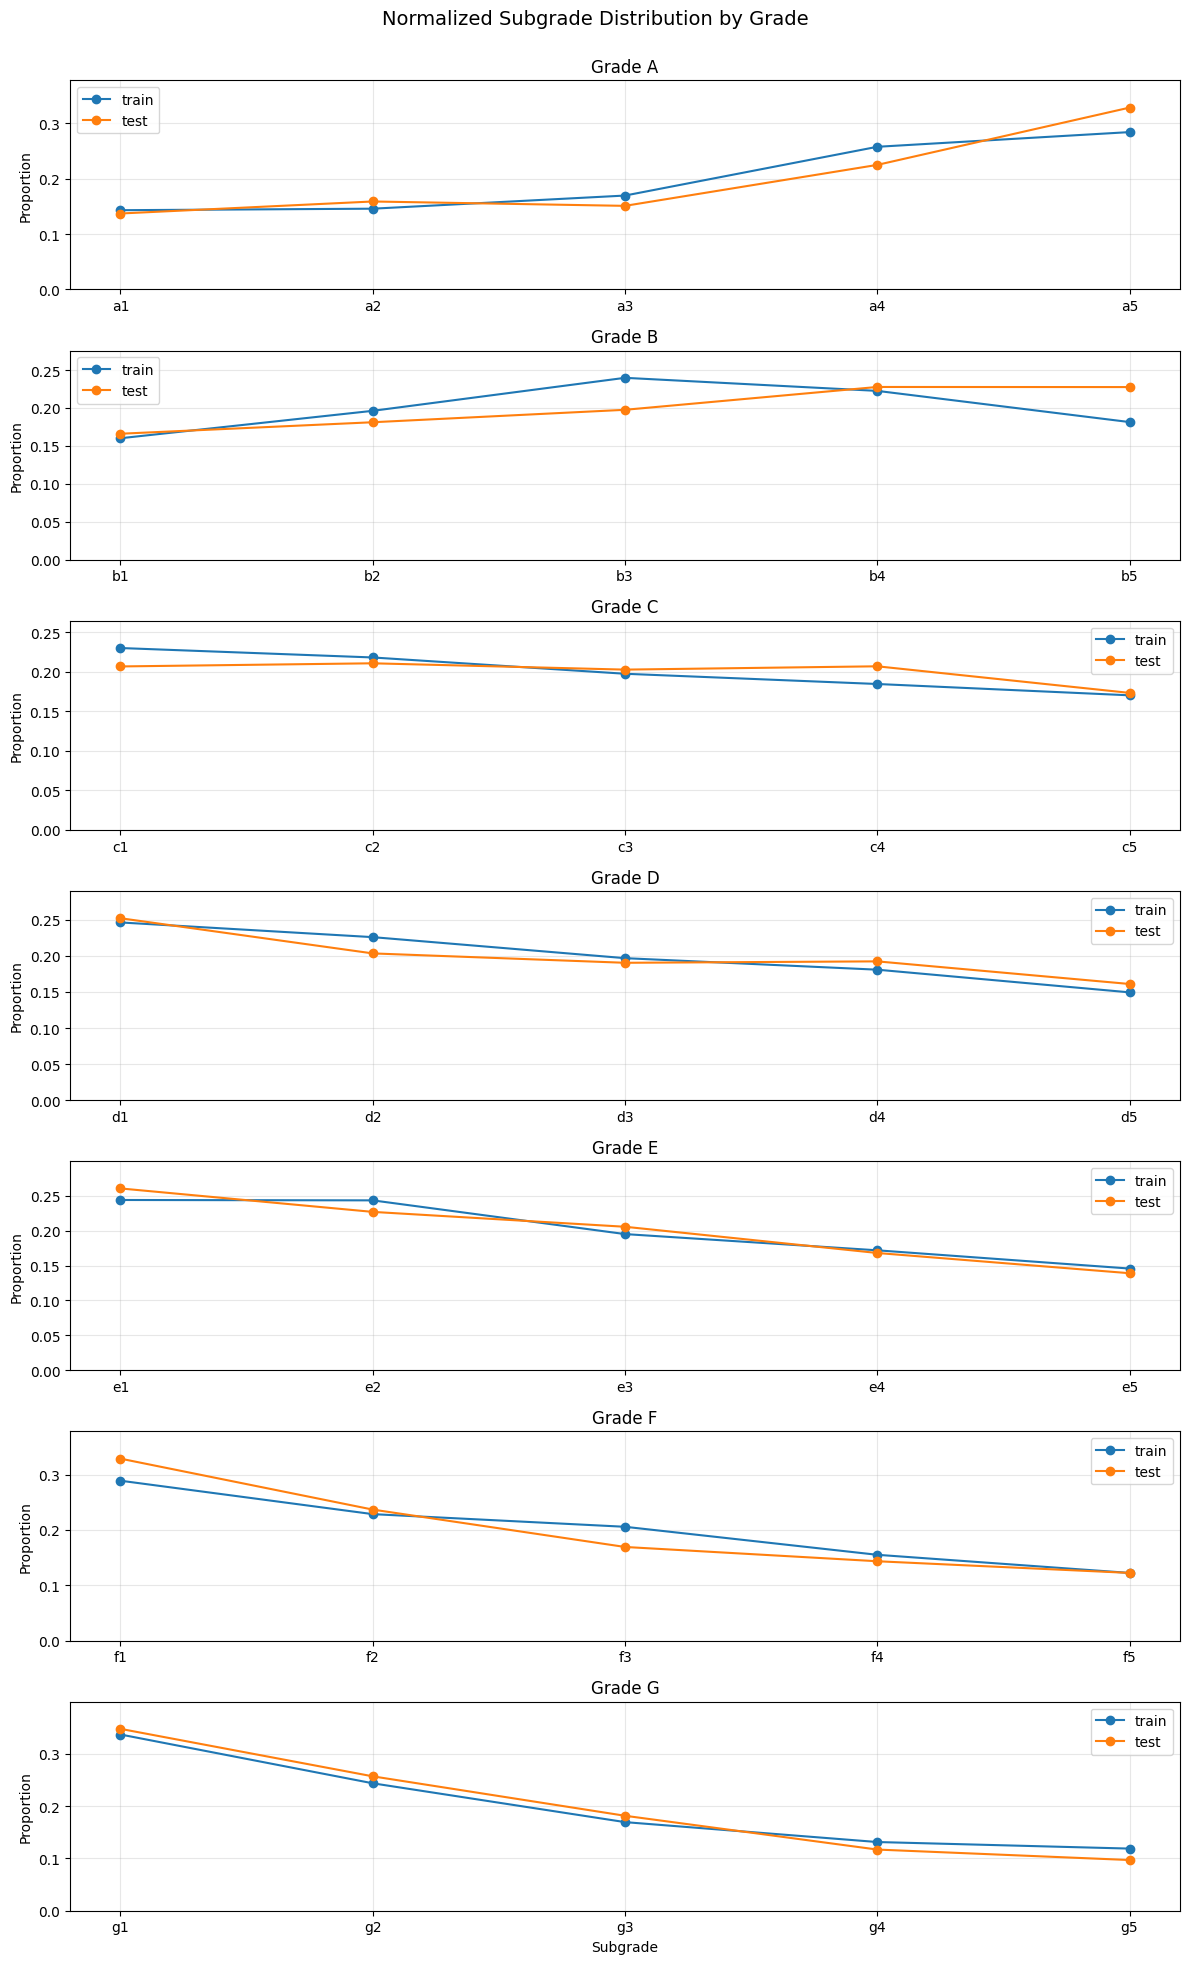

In [11]:
# --------------------------------------------------------
# Build, save, and display normalized subgrade distribution figure
# --------------------------------------------------------

figure_subgrade_distribution = vf.plot_normalized_subgrade_distribution_by_grade(
    df_subgrade_distribution_normalized=df_subgrade_distribution_normalized,
    split_column="split",
    grade_column="grade",
    log=log,
)

log("Normalized subgrade distribution figure built")

subgrade_distribution_figure_file = (
    validation_figures_dir / "normalized_subgrade_distribution_by_grade.png"
)

figure_subgrade_distribution.savefig(
    subgrade_distribution_figure_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "normalized_subgrade_distribution_figure_saved",
        "path": str(subgrade_distribution_figure_file),
    }
)

figure_subgrade_distribution

## Baseline Structure: Grade and Subgrade System

The grade-system summary shows that `sub_grade` is fully populated across both training and testing datasets. Each grade contains exactly five subgrades, with no missing values.

To understand how the grade system is used in practice, the distribution of loans within each grade was examined. These distributions are normalized, meaning that for each grade the values represent the share of loans assigned to each subgrade (e.g., 0.25 corresponds to 25% of loans within that grade).

The distributions are not uniform and reveal how LendingClub allocates borrowers within each grade.

For higher-quality grades (e.g., A), a larger share of loans is concentrated in higher-index subgrades (e.g., `a4`, `a5`). This indicates that many loans classified as Grade A are close to the boundary with Grade B, rather than representing the very lowest-risk borrowers. In other words, Grade A is used broadly, with relatively few loans at the extreme low-risk end (`a1`).

In contrast, for lower-quality grades (D–G), the pattern reverses. A larger share of loans is concentrated in lower-index subgrades (e.g., `d1`, `g1`), meaning that most loans in these grades are closer to the boundary with the previous grade than to the extreme high-risk end (`g5`). The highest-risk subgrades are used more selectively and contain relatively few loans.

Intermediate grades (B and C) show flatter distributions, where loans are more evenly spread across subgrades, indicating less concentration at either boundary.

Taken together, this suggests that LendingClub’s underwriting system is not symmetric. Higher-quality grades are used more flexibly, with many borrowers near the cutoff to the next grade, while lower-quality grades are more selective, with fewer loans assigned to the most extreme risk categories.

These patterns are consistent across training and testing datasets, indicating that this structure is stable over time rather than a sampling artifact.

An important implication is that subgrades are not equally sized. Moving a decision threshold from one subgrade to the next does not result in equal changes in loan volume, because some subgrades contain substantially more loans than others.

Overall, this confirms that `sub_grade` represents a structured and consistently applied internal ranking system. The baseline will therefore be evaluated at the `sub_grade` level, providing a complete ordering of borrowers from `a1` to `g5`.

In [12]:
# ----------------------------------------------------------------------------
# Compute, build, summarize, and save default rate by subgrade artifacts
# ----------------------------------------------------------------------------

df_default_rate_by_subgrade_train = vd.compute_default_rate_by_subgrade(
    df_validation=df_validation_train,
    target_column=metadata["target_column"],
    subgrade_column="sub_grade",
    log=log,
)

log(
    {
        "stage": "default_rate_by_subgrade_computed",
        "split": "train",
        "rows": df_default_rate_by_subgrade_train.shape[0],
        "columns": df_default_rate_by_subgrade_train.shape[1],
    }
)

df_default_rate_by_subgrade_test = vd.compute_default_rate_by_subgrade(
    df_validation=df_validation_test,
    target_column=metadata["target_column"],
    subgrade_column="sub_grade",
    log=log,
)

log(
    {
        "stage": "default_rate_by_subgrade_computed",
        "split": "test",
        "rows": df_default_rate_by_subgrade_test.shape[0],
        "columns": df_default_rate_by_subgrade_test.shape[1],
    }
)

df_default_rate_by_subgrade_train["split"] = "train"
df_default_rate_by_subgrade_test["split"] = "test"

df_default_rate_by_subgrade_combined = pd.concat(
    [df_default_rate_by_subgrade_train, df_default_rate_by_subgrade_test],
    axis=0,
    ignore_index=True,
)

df_default_rate_by_subgrade_table = va.build_default_rate_by_subgrade_table(
    df_default_rate_by_subgrade=df_default_rate_by_subgrade_combined,
    split_column="split",
    subgrade_column="sub_grade",
    log=log,
)

log(
    {
        "stage": "default_rate_by_subgrade_table_built",
        "rows": df_default_rate_by_subgrade_table.shape[0],
        "columns": df_default_rate_by_subgrade_table.shape[1],
    }
)

default_rate_by_subgrade_table_file = (
    validation_tables_dir / "default_rate_by_subgrade_table.csv"
)

df_default_rate_by_subgrade_table.to_csv(
    default_rate_by_subgrade_table_file,
    index=False,
)

log(
    {
        "stage": "default_rate_by_subgrade_table_saved",
        "path": str(default_rate_by_subgrade_table_file),
    }
)

df_default_rate_by_subgrade_summary = (
    df_default_rate_by_subgrade_table.groupby("split")["default_rate"]
    .describe()
    .reset_index()
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_default_rate_by_subgrade_summary)

,split,count,mean,std,min,25%,50%,75%,max
0,train,35.0,0.269599,0.137771,0.030808,0.150912,0.268403,0.386440,0.463014
1,test,35.0,0.257082,0.150860,0.018868,0.121322,0.266452,0.373355,0.555556


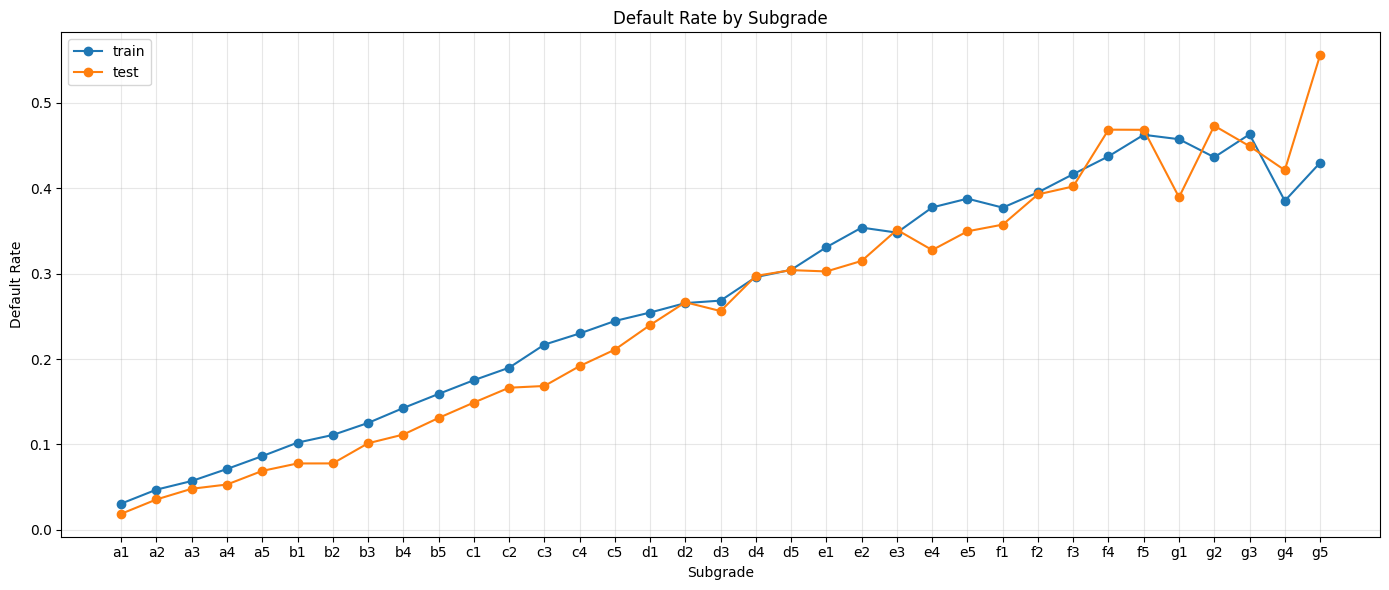

In [13]:
# --------------------------------------------------------
# Build, save, and display default rate by subgrade figure
# --------------------------------------------------------

figure_default_rate_by_subgrade = vf.plot_default_rate_by_subgrade(
    df_default_rate_by_subgrade=df_default_rate_by_subgrade_table,
    split_column="split",
    subgrade_column="sub_grade",
    default_rate_column="default_rate",
    log=log,
)

log("Default rate by subgrade figure built")

default_rate_by_subgrade_figure_file = (
    validation_figures_dir / "default_rate_by_subgrade.png"
)

figure_default_rate_by_subgrade.savefig(
    default_rate_by_subgrade_figure_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "default_rate_by_subgrade_figure_saved",
        "path": str(default_rate_by_subgrade_figure_file),
    }
)

## Baseline Structure Conclusion

The LendingClub grade system provides a structured and stable baseline for risk classification.

Subgrades are fully populated and consistently applied across both training and testing datasets. The internal distribution of loans within grades is non-uniform and reflects how LendingClub allocates borrowers in practice, with clear asymmetry between higher- and lower-quality grades. This implies that decision thresholds based on subgrades will not translate into uniform changes in loan volume.

Observed default rates confirm that `sub_grade` represents a meaningful risk ordering. Default risk increases substantially from `a1` to `g5`, and this pattern is largely consistent across training and testing data. While the highest-risk subgrades exhibit some variability due to smaller sample sizes, the overall structure remains stable.

Taken together, this indicates that the baseline system captures a significant portion of the available risk signal. As a result, any model-based improvement must come from refining this existing ordering rather than replacing it.

The baseline will therefore be evaluated at the `sub_grade` level, which provides a complete and operationally relevant ranking of borrowers.

---

## 3. Risk Evaluation

This section evaluates the selected model from two complementary perspectives.

1. **risk separation** assesses how effectively the model orders borrowers from lower risk to higher risk relative to LendingClub’s internal ranking system. This focuses on ranking quality rather than decision thresholds.

2. **calibration** assesses whether predicted default probabilities correspond to observed default rates. This is required if the model is to support threshold-based lending decisions.

Together, these analyses establish whether the model produces both a strong risk ordering and usable probability estimates before policy evaluation begins.

---

### Risk Separation

Risk separation is evaluated by comparing the model’s predicted probabilities with the subgrade-based baseline ranking.

ROC curves and AUC are computed for both systems on training and testing data to assess how effectively each orders borrowers by default risk.

---

In [14]:
# ----------------------------------------------------------------------
# Compute, save, and display ROC/AUC artifacts for model and subgrade baseline (train → test)
# ----------------------------------------------------------------------

# Model ROC/AUC (train)
df_roc_model_train = vm.compute_model_roc_auc(
    y_true=df_validation_train[metadata["target_column"]],
    y_score=df_validation_train["predicted_default_probability"],
    system_name="model",
    dataset_name="train",
    log=log,
)

log(
    {
        "stage": "roc_model_computed",
        "split": "train",
        "rows": df_roc_model_train.shape[0],
        "auc": float(df_roc_model_train["auc"].iloc[0]),
    }
)

# Model ROC/AUC (test)
df_roc_model_test = vm.compute_model_roc_auc(
    y_true=df_validation_test[metadata["target_column"]],
    y_score=df_validation_test["predicted_default_probability"],
    system_name="model",
    dataset_name="test",
    log=log,
)

log(
    {
        "stage": "roc_model_computed",
        "split": "test",
        "rows": df_roc_model_test.shape[0],
        "auc": float(df_roc_model_test["auc"].iloc[0]),
    }
)

# Baseline ROC/AUC (train)
df_roc_baseline_train = vm.compute_baseline_roc_auc_from_subgrade(
    y_true=df_validation_train[metadata["target_column"]],
    subgrade_series=df_validation_train["sub_grade"],
    system_name="baseline_subgrade",
    dataset_name="train",
    log=log,
)

log(
    {
        "stage": "roc_baseline_computed",
        "split": "train",
        "rows": df_roc_baseline_train.shape[0],
        "auc": float(df_roc_baseline_train["auc"].iloc[0]),
    }
)

# Baseline ROC/AUC (test)
df_roc_baseline_test = vm.compute_baseline_roc_auc_from_subgrade(
    y_true=df_validation_test[metadata["target_column"]],
    subgrade_series=df_validation_test["sub_grade"],
    system_name="baseline_subgrade",
    dataset_name="test",
    log=log,
)

log(
    {
        "stage": "roc_baseline_computed",
        "split": "test",
        "rows": df_roc_baseline_test.shape[0],
        "auc": float(df_roc_baseline_test["auc"].iloc[0]),
    }
)

# --------------------------------------------------------
# Build and save ROC artifacts
# --------------------------------------------------------

df_roc_curve_artifact = va.build_roc_curve_artifact_table(
    roc_auc_artifact_frames=[
        df_roc_model_train,
        df_roc_model_test,
        df_roc_baseline_train,
        df_roc_baseline_test,
    ],
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    false_positive_rate_column="false_positive_rate",
    true_positive_rate_column="true_positive_rate",
    threshold_column="threshold",
    auc_column="auc",
    log=log,
)

log(
    {
        "stage": "roc_curve_artifact_built",
        "rows": df_roc_curve_artifact.shape[0],
        "columns": df_roc_curve_artifact.shape[1],
    }
)

df_risk_separation_summary = va.build_risk_separation_summary_table(
    roc_auc_artifact_df=df_roc_curve_artifact,
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    auc_column="auc",
    log=log,
)

log(
    {
        "stage": "risk_separation_summary_built",
        "rows": df_risk_separation_summary.shape[0],
        "columns": df_risk_separation_summary.shape[1],
    }
)

roc_curve_artifact_file = validation_tables_dir / "roc_curve_artifact.csv"
risk_separation_summary_file = validation_tables_dir / "risk_separation_summary.csv"

df_roc_curve_artifact.to_csv(
    roc_curve_artifact_file,
    index=False,
)

df_risk_separation_summary.to_csv(
    risk_separation_summary_file,
    index=False,
)

log(
    {
        "stage": "risk_separation_artifacts_saved",
        "roc_curve_path": str(roc_curve_artifact_file),
        "summary_path": str(risk_separation_summary_file),
    }
)

# --------------------------------------------------------
# Quick AUC sanity check (train → test)
# --------------------------------------------------------

df_auc_quick = pd.DataFrame(
    [
        {
            "system": "model",
            "split": "train",
            "auc": float(df_roc_model_train["auc"].iloc[0]),
        },
        {
            "system": "model",
            "split": "test",
            "auc": float(df_roc_model_test["auc"].iloc[0]),
        },
        {
            "system": "baseline_subgrade",
            "split": "train",
            "auc": float(df_roc_baseline_train["auc"].iloc[0]),
        },
        {
            "system": "baseline_subgrade",
            "split": "test",
            "auc": float(df_roc_baseline_test["auc"].iloc[0]),
        },
    ]
)

df_auc_quick["split"] = pd.Categorical(
    df_auc_quick["split"],
    categories=["train", "test"],
    ordered=True,
)

df_auc_quick = df_auc_quick.sort_values(
    ["split", "system"]
).reset_index(drop=True)

display(df_auc_quick)

,system,split,auc
0,baseline_subgrade,train,0.678294
1,model,train,0.748522
2,baseline_subgrade,test,0.691944
3,model,test,0.723228


### Risk Separation — Conclusion

The model improves risk separation relative to LendingClub’s grading system, indicating that additional predictive signal is available beyond the subgrade-based baseline.

The remaining question is whether this improvement translates into better lending decisions, in terms of reduced default exposure and preserved lending volume.

---

### Calibration

Calibration assesses whether predicted default probabilities correspond to observed default rates.

This is required for threshold-based decision-making, as reliable probability estimates determine whether a given acceptance rule reflects the intended level of risk.

---

In [15]:
# ----------------------------------------------------------------------
# Compute, save, and display calibration artifacts (train → test)
# ----------------------------------------------------------------------

df_calibration_train = vm.compute_calibration_table(
    y_true=df_validation_train[metadata["target_column"]],
    y_score=df_validation_train["predicted_default_probability"],
    system_name="model",
    dataset_name="train",
    n_bins=10,
    log=log,
)

log(
    {
        "stage": "calibration_table_computed",
        "split": "train",
        "rows": df_calibration_train.shape[0],
        "columns": df_calibration_train.shape[1],
    }
)

df_calibration_test = vm.compute_calibration_table(
    y_true=df_validation_test[metadata["target_column"]],
    y_score=df_validation_test["predicted_default_probability"],
    system_name="model",
    dataset_name="test",
    n_bins=10,
    log=log,
)

log(
    {
        "stage": "calibration_table_computed",
        "split": "test",
        "rows": df_calibration_test.shape[0],
        "columns": df_calibration_test.shape[1],
    }
)

df_calibration_artifact = va.build_calibration_artifact_table(
    calibration_tables=[
        df_calibration_train,
        df_calibration_test,
    ],
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    bin_order_column="bin_order",
    log=log,
)

log(
    {
        "stage": "calibration_artifact_built",
        "rows": df_calibration_artifact.shape[0],
        "columns": df_calibration_artifact.shape[1],
    }
)

calibration_artifact_file = validation_tables_dir / "calibration_artifact.csv"

df_calibration_artifact.to_csv(
    calibration_artifact_file,
    index=False,
)

log(
    {
        "stage": "calibration_artifact_saved",
        "path": str(calibration_artifact_file),
    }
)

display(df_calibration_artifact)

,system_name,dataset_name,bin_order,calibration_bin,row_count,predicted_probability_mean,observed_default_rate,predicted_probability_min,predicted_probability_max
0,model,train,1,"(0.0033, 0.0622]",28295,0.045029,0.031878,0.004305,0.062188
1,model,train,2,"(0.0622, 0.086]",28294,0.074422,0.059589,0.062189,0.086040
2,model,train,3,"(0.086, 0.108]",28295,0.097214,0.082347,0.086040,0.108285
3,model,train,4,"(0.108, 0.132]",28294,0.119754,0.106524,0.108285,0.131555
4,model,train,5,"(0.132, 0.157]",28295,0.144185,0.132356,0.131556,0.157478
5,model,train,6,"(0.157, 0.188]",28294,0.172115,0.164629,0.157479,0.187763
6,model,train,7,"(0.188, 0.226]",28294,0.206052,0.202658,0.187763,0.225857
7,model,train,8,"(0.226, 0.277]",28295,0.250235,0.251564,0.225859,0.277492
8,model,train,9,"(0.277, 0.362]",28294,0.315234,0.331554,0.277500,0.361656
9,model,train,10,"(0.362, 0.959]",28295,0.460568,0.522283,0.361662,0.959240


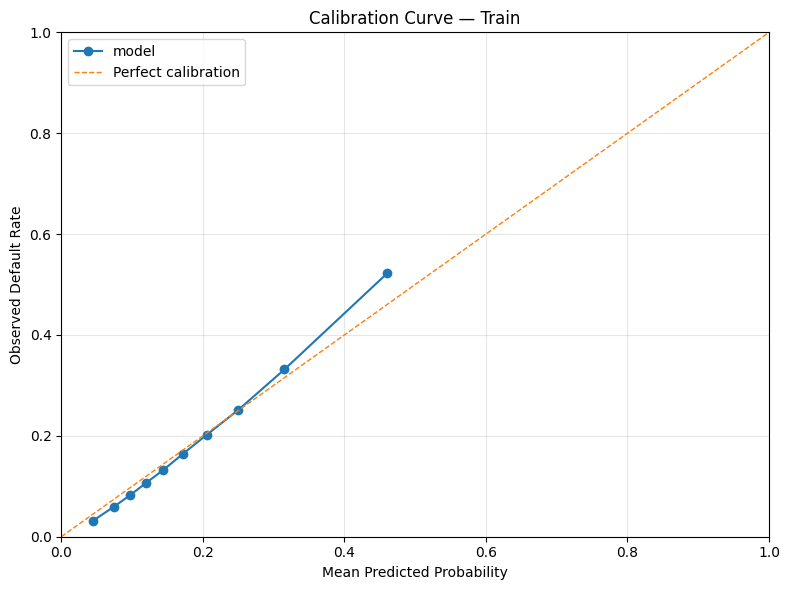

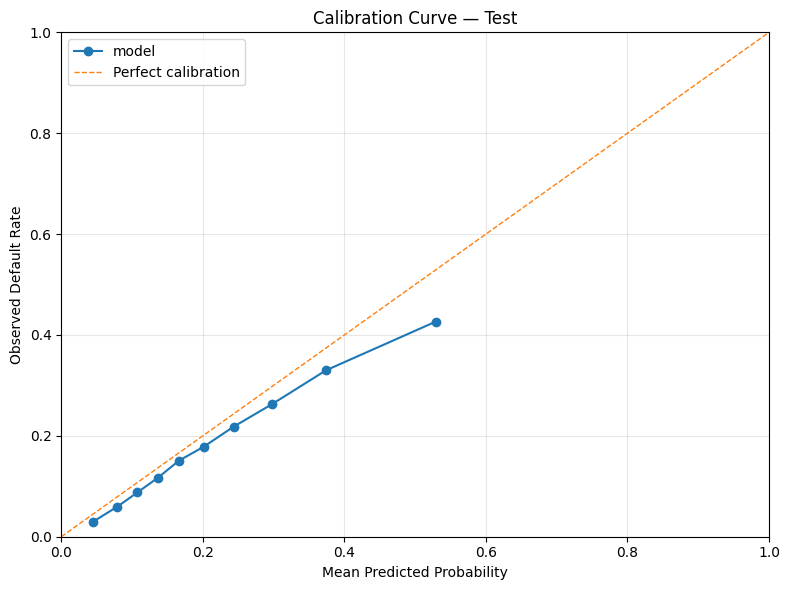

In [19]:
# ----------------------------------------------------------------------
# Build, save, and display calibration figures (train → test)
# ----------------------------------------------------------------------

figure_calibration_train = vf.plot_calibration_curve(
    df_calibration_artifact=df_calibration_artifact,
    dataset_name="train",
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    predicted_probability_column="predicted_probability_mean",
    observed_default_rate_column="observed_default_rate",
    log=log,
)

calibration_train_figure_file = validation_figures_dir / "calibration_curve_train.png"

figure_calibration_train.savefig(
    calibration_train_figure_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "calibration_curve_train_saved",
        "path": str(calibration_train_figure_file),
    }
)

figure_calibration_test = vf.plot_calibration_curve(
    df_calibration_artifact=df_calibration_artifact,
    dataset_name="test",
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    predicted_probability_column="predicted_probability_mean",
    observed_default_rate_column="observed_default_rate",
    log=log,
)

calibration_test_figure_file = validation_figures_dir / "calibration_curve_test.png"

figure_calibration_test.savefig(
    calibration_test_figure_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "calibration_curve_test_saved",
        "path": str(calibration_test_figure_file),
    }
)

### Calibration — Conclusion

The model is reasonably well calibrated across the low-to-middle probability range in both training and testing data. Predicted default probabilities track observed default rates closely enough to support threshold-based evaluation.

Calibration is less stable in the highest-risk region, where the relationship between predicted and observed risk becomes less consistent across training and testing data. This suggests that the model’s probabilities are usable for policy analysis, but that decisions targeting the extreme upper tail should be interpreted with additional caution.

Overall, the results indicate that the model provides probability estimates that are sufficiently reliable for decision evaluation, while also highlighting that calibration is weaker at the highest predicted risk levels.

### Calibration — Conclusion

The model is reasonably well calibrated across the low-to-middle probability range in both training and testing data. Predicted default probabilities track observed default rates closely enough to support threshold-based evaluation.

Calibration is less stable in the highest-risk region, where the relationship between predicted and observed risk becomes less consistent across training and testing data. This suggests that the model’s probabilities are usable for policy analysis, but that decisions targeting the extreme upper tail should be interpreted with additional caution.

Overall, the results indicate that the model provides probability estimates that are sufficiently reliable for decision evaluation, while also highlighting that calibration is weaker at the highest predicted risk levels.

---

## Risk Evaluation — Conclusion

The model demonstrates improved risk separation relative to the subgrade-based baseline, indicating that additional predictive signal is available beyond LendingClub’s grading system. This improvement is consistent across training and testing data, although more modest out of sample.

Calibration results show that predicted default probabilities broadly align with observed default rates across the low-to-middle probability range. This indicates that the model produces probability estimates that are sufficiently reliable for threshold-based decision-making. Calibration is less stable in the highest-risk region, where predicted and observed risk diverge more noticeably.

Taken together, these results indicate that the model provides both a stronger risk ordering and usable probability estimates. While not perfectly calibrated in all regions, particularly at the upper tail, the model is sufficiently well-behaved to support policy simulation.

The next step is therefore to evaluate whether these improvements translate into better lending decisions in terms of default risk and lending volume.

---

## 4. Policy Simulation

This section evaluates how the model and the subgrade-based baseline perform when translated into lending decisions.

For a range of acceptance policies, both systems are used to simulate which loans would be approved or rejected. The resulting portfolios are compared in terms of default rates, error types, and loan exposure.

This allows direct assessment of how each approach trades off risk reduction against lending volume, and whether the model’s improvements translate into meaningful decision outcomes.

---